In [2]:
from matplotlib.patches import Rectangle
import warnings
import logging
# Ignore all warnings
warnings.filterwarnings('ignore')
# Ignore warnings
warnings. filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
def plot_origin_vs_synthetic_pathways(
    IpiSubgroups: dict,
    pathways: list,
    subgroups: list = ['Overall', 'IpiTreated', 'IpiNaive'],
    figsize=(18, 8),
    savepath=None,
    custom_palette:  dict = None,
):
    """
    Vẽ biểu đồ so sánh q-value giữa Origin và các synthetic datasets
    
    Parameters:
    -----------
    IpiSubgroups : dict
        Dictionary chứa dữ liệu, với keys là tên dataset ('Origin', 'Avatars K5', etc.)
        và values là dict chứa DataFrame cho mỗi subgroup
    pathways : list
        Danh sách các pathway cần vẽ
    subgroups : list
        Danh sách các subgroups (Overall, IpiTreated, IpiNaive)
    figsize : tuple
        Kích thước figure
    savepath : str
        Đường dẫn để lưu figure
    custom_palette : dict
        Màu sắc cho từng subgroup
    """
    # Default palette for subgroups
    if custom_palette is None: 
        custom_palette = {
            'Overall':  '#E41A1C', 
            'IpiTreated': '#377EB8', 
            'IpiNaive': '#4DAF4A'
        }
    
    # Dataset colors
    DATASET_COLORS = {
        "Origin": "#4d4d4d",
        "Avatars K5": "#66c2a5",
        "Avatars K10": "#fc8d62",
        "CTGAN": "#8da0cb",
        "Gaussian Copula":  "#e78ac3",
        "Synthpop": "#a6d854",
        "TVAE": "#ffd92f",
    }
    
    # Prepare data
    datasets_order = ['Origin', 'Avatars K5', 'Avatars K10', 'CTGAN', 
                      'Gaussian Copula', 'Synthpop', 'TVAE']
    
    # Create combined DataFrame
    combined_data = []
    for dataset_name, subgroup_data in IpiSubgroups.items():
        for subgroup_name, df in subgroup_data.items():
            for _, row in df.iterrows():
                combined_data.append({
                    'Dataset': dataset_name,
                    'Subgroup': subgroup_name,
                    'Pathway': row['Term'],
                    'FDR_q_val': row['FDR q-val'],
                    '-Log10Qvalue': -np. log10(row['FDR q-val']) if row['FDR q-val'] > 0 else 4
                })
    
    graphDF_final = pd.DataFrame(combined_data)
    
    # Create subplots:  rows = pathways, cols = datasets
    nrows = len(pathways)
    ncols = len(datasets_order)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, 
                             gridspec_kw={'wspace':  0.15, 'hspace': 0.25})
    
    # Ensure axes is 2D array
    if nrows == 1: 
        axes = axes.reshape(1, -1)
    if ncols == 1:
        axes = axes.reshape(-1, 1)
    
    # Build legend handles
    legend_handles = [Rectangle((0, 0), 1, 1, fc=custom_palette[sg]) for sg in subgroups]
    
    # Pathway labels mapping
    pathway_labels = {
        'HALLMARK_INTERFERON_ALPHA_RESPONSE':  'FDR q-val of IFN alpha',
        'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'FDR q-val of IFN gamma'
    }
    
    for row_idx, pathway in enumerate(pathways):
        for col_idx, dataset in enumerate(datasets_order):
            ax = axes[row_idx, col_idx]
            
            # Filter data
            plot_data = graphDF_final[
                (graphDF_final["Pathway"] == pathway) & 
                (graphDF_final["Dataset"] == dataset)
            ]
            
            # Plot
            sns.barplot(
                ax=ax,
                x='Subgroup',
                y='-Log10Qvalue',
                hue='Subgroup',
                data=plot_data,
                dodge=False,
                palette=custom_palette,
                order=subgroups,
                hue_order=subgroups,
            )
            
            # Formatting
            # Title only on first row with colored strip below
            if row_idx == 0:
                ax.set_title(dataset, fontsize=9, fontweight='bold', pad=10)
                
                # Add colored strip below title
                strip_height = 0.015
                strip_y = 1.015
                dataset_color = DATASET_COLORS. get(dataset, "#cccccc")
                ax.add_patch(Rectangle(
                    (0, strip_y), 1, strip_height,
                    transform=ax.transAxes,
                    facecolor=dataset_color,
                    edgecolor='none',
                    clip_on=False,
                    zorder=10
                ))
            
            # Y-axis configuration
            yticks_val = [0, 1, 2, 3, 4]
            yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
            ax. set_yticks(yticks_val)
            ax.set_yticklabels(yticklabels_val)
            
            # Significance line
            yline = 1.0
            xlim_max = len(subgroups) - 0.5
            ax.plot([-0.5, xlim_max], [yline, yline], 
                   color='red', linestyle='--', linewidth=1, alpha=0.6)
            
            # Limits
            ax.set_xlim(-0.5, xlim_max)
            ax.set_ylim(0, 4.1)
            
            # Remove x-axis labels
            ax.set_xlabel("")
            ax.set_xticklabels([])
            
            # Y-axis label only on first column
            if col_idx == 0:
                ylabel = pathway_labels.get(pathway, "FDR q-value")
                ax.set_ylabel(ylabel, fontsize=11, labelpad=5)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis='y', labelleft=False)
            
            # Remove seaborn legend
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
    
    # Add global legend
    fig.legend(
        handles=legend_handles,
        labels=subgroups,
        loc='center left',
        bbox_to_anchor=(0.92, 0.5),
        title="Subgroup",
        frameon=True,
        fontsize=11,
        title_fontsize=12,
    )
    
    # Overall title
    # fig.suptitle('Comparison of Interferon Pathway Enrichment:  Original vs Synthetic Data', 
    #              fontsize=16, fontweight='bold', y=0.99)
    fig.suptitle('', 
                 fontsize=12, fontweight='bold', y=0.99)    
    plt.tight_layout()
    
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    
    plt.show()
    return fig

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# seeds = [0,1,2,3,42]
seeds = [2]
for seed in seeds:
    term = ['HALLMARK_INTERFERON_ALPHA_RESPONSE','HALLMARK_INTERFERON_GAMMA_RESPONSE']
    # DataSeed_Path ={
    #     'avatarsk5': 0,
    #     'avatarsk10': 3,
    #     'ctgan': 42, #1
    #    'gaussiancopula': 2,
    #     'synthpop': 42, 
    #     'tvae': 2
    # }
    DataSeed_Path ={
        'avatarsk5': seed,
        'avatarsk10': seed,
        'ctgan': seed, #1
       'gaussiancopula': seed,
        'synthpop': seed, 
        'tvae': seed
    }
    #Melanoma 
    IpiSubgroups = {}
    names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
    or_grouped = {}
    gsea_res_overall = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_42/GSEA_Origin.csv')
    gsea_res_overall = gsea_res_overall[gsea_res_overall['Term'].isin(term)][['Term','FDR q-val']]
    or_grouped['Overall']=gsea_res_overall
    
    gsea_res_ipitreated = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/Ipitreated/Seed_42/GSEA_Origin.csv')
    gsea_res_ipitreated = gsea_res_ipitreated[gsea_res_ipitreated['Term'].isin(term)][['Term','FDR q-val']]
    or_grouped['IpiTreated']=gsea_res_ipitreated
    
    gsea_res_ipinaive = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/Ipinaive/Seed_42/GSEA_Origin.csv')
    gsea_res_ipinaive = gsea_res_ipinaive[gsea_res_ipinaive['Term'].isin(term)][['Term','FDR q-val']]
    or_grouped['IpiNaive']=gsea_res_ipinaive
    
    IpiSubgroups['Origin'] = or_grouped
    for i, tool in enumerate(names): 
        syn_grouped = {}
        
        dataset = list(DataSeed_Path.keys())[i]
        seed = list(DataSeed_Path.values())[i]
        
        gsea_res_overall = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_{seed}/GSEA_{dataset}_{seed}.csv')
        gsea_res_overall = gsea_res_overall[gsea_res_overall['Term'].isin(term)][['Term','FDR q-val']]
        syn_grouped['Overall']=gsea_res_overall
        
        gsea_res_ipitreated = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/Ipitreated/Seed_{seed}/GSEA_{dataset}_{seed}.csv')
        gsea_res_ipitreated = gsea_res_ipitreated[gsea_res_ipitreated['Term'].isin(term)][['Term','FDR q-val']]
        syn_grouped['IpiTreated']=gsea_res_ipitreated
        
        gsea_res_ipinaive = pd.read_csv(f'../Melanoma/NarrowUtility/GSEA/Ipinaive/Seed_{seed}/GSEA_{dataset}_{seed}.csv')
        gsea_res_ipinaive = gsea_res_ipinaive[gsea_res_ipinaive['Term'].isin(term)][['Term','FDR q-val']]
        syn_grouped['IpiNaive']=gsea_res_ipinaive
        IpiSubgroups[names[i]] = syn_grouped

        Sử dụng function
    fig = plot_origin_vs_synthetic_pathways(
        IpiSubgroups=IpiSubgroups,
        pathways=term,
        subgroups=['Overall', 'IpiTreated', 'IpiNaive'],
        figsize=(9, 5),
        savepath=None
    )
    # fig.savefig("MelanomaIpiTreatedNaive.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(f"IpiSubgroupInterferon/Seed_{seed}.pdf", dpi=300, bbox_inches="tight", facecolor="white")

In [17]:
from matplotlib.patches import Rectangle
import warnings
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore all warnings
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


def _draw_seed_loading_bar(
    ax: plt.Axes,
    seeds: list,
    mask: list,
    loc: tuple = (0.0, 1.015),
    height: float = 0.015,
    gap: float = 0.01,
    true_color: str = "#3182bd",
    false_color: str = "#efefef",
    edge_color: str = "k",
):
    """
    Draw a horizontal loading bar spanning full axes width (by default) with one cell per seed.

    - loc: (x0, y0) in axes coordinates for the left-bottom corner of the bar (x0 usually 0.0).
    - height: height of the bar in axes coordinates (e.g. 0.015 same as previous strip).
    - gap: gap between cells in axes coordinates.
    - mask: list of booleans where True -> fill with true_color, False -> false_color.
    """
    x0, y0 = loc
    n = len(seeds)
    if n <= 0:
        return
    total_gap = gap * (n - 1)
    # compute cell width so that the entire bar (cells + gaps) occupies width 1.0 starting at x0
    # If x0 != 0, we still limit to remaining width (1.0 - x0)
    avail_width = max(0.0, 1.0 - x0)
    cell_w = max(0.0, (avail_width - total_gap) / n)

    for i, m in enumerate(mask):
        xi = x0 + i * (cell_w + gap)
        rect = Rectangle(
            (xi, y0),
            cell_w,
            height,
            transform=ax.transAxes,
            facecolor=true_color if m else false_color,
            edgecolor=edge_color,
            linewidth=0.6,
            clip_on=False,
            zorder=30,
        )
        ax.add_patch(rect)


def plot_origin_vs_synthetic_pathways(
    IpiSubgroups: dict,
    pathways: list,
    subgroups: list = ['Overall', 'IpiTreated', 'IpiNaive'],
    seeds: list = [0, 1, 2, 3, 42],
    figsize=(18, 8),
    savepath=None,
    custom_palette: dict = None,
):
    """
    Vẽ comparison plots giữa Origin và synthetic datasets, hiển thị loading-bar 5 ô
    ngay phía trên subplot (thay cho color strip). Tên dataset được tô màu tương ứng.

    IpiSubgroups: dict[dataset_name] -> dict[subgroup_name] -> DataFrame
        Each DataFrame must include columns: 'Term', 'FDR q-val', 'Seed' (Seed = int or identifier).
    Condition per seed for coloring a cell: (FDR_IpiTreated < 0.05) AND (FDR_IpiNaive > 0.05)
    """
    # Default palette for subgroups
    if custom_palette is None:
        custom_palette = {
            'Overall': '#E41A1C',
            'IpiTreated': '#377EB8',
            'IpiNaive': '#4DAF4A'
        }

    # Dataset colors
    DATASET_COLORS = {
        "Origin": "#4d4d4d",
        "Avatars K5": "#66c2a5",
        "Avatars K10": "#fc8d62",
        "CTGAN": "#8da0cb",
        "Gaussian Copula": "#e78ac3",
        "Synthpop": "#a6d854",
        "TVAE": "#ffd92f",
    }

    # Ensure required imports present
    datasets_order = list(IpiSubgroups.keys())

    # Build combined long DataFrame (include Seed)
    combined_data = []
    for dataset_name, subgroup_data in IpiSubgroups.items():
        for subgroup_name, df in subgroup_data.items():
            # Expect df to have columns ['Term','FDR q-val','Seed']
            if df is None or df.empty:
                continue
            for _, row in df.iterrows():
                fq = row.get('FDR q-val', np.nan)
                # safe numeric
                try:
                    fq = float(fq)
                except Exception:
                    fq = np.nan
                combined_data.append({
                    'Dataset': dataset_name,
                    'Subgroup': subgroup_name,
                    'Pathway': row['Term'],
                    'FDR_q_val': fq,
                    '-Log10Qvalue': -np.log10(fq) if (not pd.isna(fq) and fq > 0) else 4.0,
                    'Seed': row.get('Seed', None),
                })

    graphDF_final = pd.DataFrame(combined_data)

    # Create subplots: rows = pathways, cols = datasets
    nrows = len(pathways)
    ncols = len(datasets_order)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             gridspec_kw={'wspace': 0.15, 'hspace': 0.25})

    # Ensure axes is 2D array
    if nrows == 1:
        axes = axes.reshape(1, -1)
    if ncols == 1:
        axes = axes.reshape(-1, 1)

    # Build legend handles
    legend_handles = [Rectangle((0, 0), 1, 1, fc=custom_palette[sg]) for sg in subgroups]

    # Pathway labels mapping (extend as needed)
    pathway_labels = {p: p for p in pathways}
    pathway_labels = {
    'HALLMARK_INTERFERON_ALPHA_RESPONSE': 'IFN Alpha',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'IFN Gamma'
}
    # significance line at q = 0.05 -> -log10(0.05)
    yline = -np.log10(0.05)

    for row_idx, pathway in enumerate(pathways):
        for col_idx, dataset in enumerate(datasets_order):
            ax = axes[row_idx, col_idx]

            # Filter data for plotting bars
            plot_data = graphDF_final[
                (graphDF_final["Pathway"] == pathway) &
                (graphDF_final["Dataset"] == dataset)
            ]

            # If empty, show "No data"
            if plot_data.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
                ax.set_xlim(-0.5, len(subgroups) - 0.5)
                ax.set_ylim(0, 4.1)
                ax.set_xlabel("")
                ax.set_xticklabels([])
                if col_idx == 0:
                    ax.set_ylabel(pathway_labels.get(pathway, "FDR q-value"))
                else:
                    ax.tick_params(axis='y', labelleft=False)
                continue

            # For barplot, use median -Log10Qvalue across seeds for plotting the bar heights
            bar_df = (
                plot_data.groupby('Subgroup')['-Log10Qvalue']
                .median()
                .reindex(subgroups)
                .reset_index()
                .rename(columns={'-Log10Qvalue': '-Log10Qvalue_median'})
            )

            # In case some subgroup missing -> fill 0
            bar_df['-Log10Qvalue_median'] = bar_df['-Log10Qvalue_median'].fillna(0.0)

            # Color title text with dataset color (instead of drawing color strip)
            dataset_color = DATASET_COLORS.get(dataset, "#333333")

            sns.barplot(
                ax=ax,
                x='Subgroup',
                y='-Log10Qvalue_median',
                hue='Subgroup',
                data=bar_df,
                dodge=False,
                palette=custom_palette,
                order=subgroups,
                hue_order=subgroups,
            )

            # Draw significance horizontal line at q=0.05
            xlim_max = len(subgroups) - 0.5
            ax.plot([-0.5, xlim_max], [yline, yline],
                    color='red', linestyle='--', linewidth=1, alpha=0.8)

            # Formatting
            if row_idx == 0:
                # set colored title (dataset name) instead of strip
                ax.set_title(dataset, fontsize=9, fontweight='bold', pad=10, color=dataset_color)
            else:
                # still set title but uncolored for other rows
                ax.set_title(dataset, fontsize=9, fontweight='bold', pad=10, color=dataset_color)

            # Y-axis ticks and labels: map -log10 q-values to readable labels
            yticks_val = [0, 1, 2, 3, 4]
            yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
            ax.set_yticks(yticks_val)
            ax.set_yticklabels(yticklabels_val)

            ax.set_xlim(-0.5, xlim_max)
            ax.set_ylim(0, 4.1)

            # Remove x-axis labels but keep tick positions
            ax.set_xlabel("")
            ax.set_xticklabels([])

            # Y-axis label only on first column
            if col_idx == 0:
                pathway_label = pathway_labels.get(pathway, pathway)
                ylabel = f"{pathway_label}\nFDR q-value"
                ax.set_ylabel(ylabel, fontsize=9, labelpad=5)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis='y', labelleft=False)

            # Remove seaborn legend
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

            # Draw loading-bar for synthetic datasets (skip 'Origin')
            if dataset != 'Origin':
                # For each seed in seeds check condition: FDR_IpiTreated < 0.05 AND FDR_IpiNaive > 0.05
                mask = []
                for s in seeds:
                    # get FDRs for this dataset, pathway, seed
                    row_treated = plot_data[(plot_data['Subgroup'] == 'IpiTreated') & (plot_data['Seed'] == s)]
                    row_naive = plot_data[(plot_data['Subgroup'] == 'IpiNaive') & (plot_data['Seed'] == s)]

                    ft = None
                    fn = None
                    if not row_treated.empty:
                        ft = row_treated['FDR_q_val'].values[0]
                    if not row_naive.empty:
                        fn = row_naive['FDR_q_val'].values[0]

                    # Evaluate condition; require both values present
                    if (ft is not None and not pd.isna(ft)) and (fn is not None and not pd.isna(fn)):
                        cond = (ft < 0.05) and (fn > 0.05)
                        mask.append(bool(cond))
                    else:
                        # missing -> show as False (empty / gray)
                        mask.append(False)

                # place loading-bar at the former strip location (spans full width)
                loc = (0.0, 1.015)  # left-bottom of bar in axes coordinates (same position as old strip)
                _draw_seed_loading_bar(ax=ax, seeds=seeds, mask=mask, loc=loc, height=0.03, gap=0.01)

    # Add global legend for subgroups (right)
    fig.legend(
        handles=legend_handles,
        labels=subgroups,
        loc='center left',
        bbox_to_anchor=(0.92, 0.5),
        title="Subgroup",
        frameon=True,
        fontsize=11,
        title_fontsize=12,
    )

    fig.suptitle('', fontsize=12, fontweight='bold', y=0.99)
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    return fig

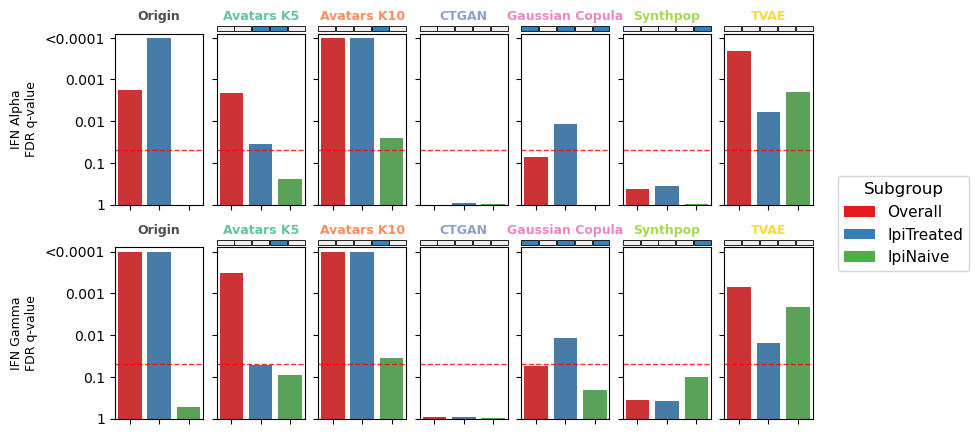

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from plot_origin_vs_synthetic import plot_origin_vs_synthetic_pathways

# seeds to combine across
seeds = [0, 1, 2, 3, 42]

# pathways of interest
terms = ['HALLMARK_INTERFERON_ALPHA_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE']

# dataset mapping short->display
DataSeed_Path = {
    'avatarsk5': 'Avatars K5',
    'avatarsk10': 'Avatars K10',
    'ctgan': 'CTGAN',
    'gaussiancopula': 'Gaussian Copula',
    'synthpop': 'Synthpop',
    'tvae': 'TVAE'
}
names = list(DataSeed_Path.values())
shorts = list(DataSeed_Path.keys())

# Build IpiSubgroups: dict[dataset_display] -> dict[subgroup] -> DataFrame with Seed column
IpiSubgroups = {}

# Origin (we assume origin files under Seed_42 as before)
origin_base = '../Melanoma/NarrowUtility/GSEA'
# read origin overall + subgroups (Origin may have separate folders)
or_grouped = {}
# Overall origin
p = f'{origin_base}/CRPR_PD/Seed_42/GSEA_Origin.csv'
df_overall = pd.read_csv(p)
df_overall = df_overall[df_overall['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_overall['Seed'] = 'origin'
or_grouped['Overall'] = df_overall

# IpiTreated origin
p = f'{origin_base}/Ipitreated/Seed_42/GSEA_Origin.csv'
df_it = pd.read_csv(p)
df_it = df_it[df_it['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_it['Seed'] = 'origin'
or_grouped['IpiTreated'] = df_it

# IpiNaive origin
p = f'{origin_base}/Ipinaive/Seed_42/GSEA_Origin.csv'
df_in = pd.read_csv(p)
df_in = df_in[df_in['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_in['Seed'] = 'origin'
or_grouped['IpiNaive'] = df_in

IpiSubgroups['Origin'] = or_grouped

# For each synthetic dataset, collect per-seed results and concatenate for each subgroup
for short_name, display_name in DataSeed_Path.items():
    grouped = {}
    # collect across seeds for each subgroup
    dfs_overall = []
    dfs_it = []
    dfs_in = []
    for s in seeds:
        # try reading files; skip if missing
        p_overall = f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_{s}/GSEA_{short_name}_{s}.csv'
        p_it = f'../Melanoma/NarrowUtility/GSEA/Ipitreated/Seed_{s}/GSEA_{short_name}_{s}.csv'
        p_in = f'../Melanoma/NarrowUtility/GSEA/Ipinaive/Seed_{s}/GSEA_{short_name}_{s}.csv'

        try:
            df_o = pd.read_csv(p_overall)
            df_o = df_o[df_o['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_o['Seed'] = int(s)
            dfs_overall.append(df_o)
        except FileNotFoundError:
            # skip missing
            pass

        try:
            df_t = pd.read_csv(p_it)
            df_t = df_t[df_t['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_t['Seed'] = int(s)
            dfs_it.append(df_t)
        except FileNotFoundError:
            pass

        try:
            df_n = pd.read_csv(p_in)
            df_n = df_n[df_n['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_n['Seed'] = int(s)
            dfs_in.append(df_n)
        except FileNotFoundError:
            pass

    grouped['Overall'] = pd.concat(dfs_overall, ignore_index=True) if len(dfs_overall) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])
    grouped['IpiTreated'] = pd.concat(dfs_it, ignore_index=True) if len(dfs_it) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])
    grouped['IpiNaive'] = pd.concat(dfs_in, ignore_index=True) if len(dfs_in) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])

    IpiSubgroups[display_name] = grouped

# Use the plotting function to create the figure that aggregates seeds
fig = plot_origin_vs_synthetic_pathways(
    IpiSubgroups=IpiSubgroups,
    pathways=terms,
    subgroups=['Overall', 'IpiTreated', 'IpiNaive'],
    seeds=seeds,
    figsize=(9, 5),
    savepath=None
)

fig.savefig(f"IpiSubgroupInterferon/CombinedSeeds_Melanoma.pdf", dpi=300, bbox_inches="tight", facecolor="white")

In [39]:
from matplotlib.patches import Rectangle
import warnings
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore all warnings
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


def plot_origin_vs_synthetic_pathways(
    IpiSubgroups: dict,
    pathways: list,
    subgroups: list = ['Overall', 'IpiTreated', 'IpiNaive'],
    seeds: list = [0, 1, 2, 3, 42],
    figsize=(18, 8),
    savepath=None,
    custom_palette: dict = None,
):
    """
    Vẽ comparison plots giữa Origin và synthetic datasets — mỗi dot là 1 replicate (Seed).
    - Tất cả dots dùng hình tròn (circle marker).
    - KHÔNG nối các điểm (bỏ đường kết nối).
    - Các điểm trong cùng 1 cột (subgroup) được căn thẳng hàng (cùng x), dùng jitter dọc (vertical) để tránh overlap.
    - Replicate thỏa điều kiện (Treated<0.05 & Naive>0.05): tô 1 màu duy nhất, được vẽ TRƯỚC (zorder cao hơn).
    - Replicate không thỏa: màu xám, vẽ sau (zorder thấp hơn).
    - Viền tất cả dots: màu đen.
    - Bỏ legend.
    - Xtick labels (subgroup names) chỉ hiển thị ở hàng cuối, xoay 90 độ, căn giữa.
    - Clamp y values để không vượt quá [0, 4.1].
    """
    # Màu cho replicate thỏa điều kiện (1 màu duy nhất)
    PASS_COLOR = '#3182bd'  # xanh dương đậm
    FAIL_COLOR = '#bdbdbd'  # xám

    # Dataset colors (used for title only)
    DATASET_COLORS = {
        "Origin": "#4d4d4d",
        "Avatars K5": "#66c2a5",
        "Avatars K10": "#fc8d62",
        "CTGAN": "#8da0cb",
        "Gaussian Copula": "#e78ac3",
        "Synthpop": "#a6d854",
        "TVAE": "#ffd92f",
    }

    datasets_order = list(IpiSubgroups.keys())

    # Build combined long DataFrame (include Seed)
    combined_data = []
    for dataset_name, subgroup_data in IpiSubgroups.items():
        for subgroup_name, df in subgroup_data.items():
            # Expect df to have columns ['Term','FDR q-val','Seed']
            if df is None or df.empty:
                continue
            for _, row in df.iterrows():
                fq = row.get('FDR q-val', np.nan)
                # safe numeric
                try:
                    fq = float(fq)
                except Exception:
                    fq = np.nan
                combined_data.append({
                    'Dataset': dataset_name,
                    'Subgroup': subgroup_name,
                    'Pathway': row['Term'],
                    'FDR_q_val': fq,
                    '-Log10Qvalue': -np.log10(fq) if (not pd.isna(fq) and fq > 0) else 4.0,
                    'Seed': row.get('Seed', None),
                })

    graphDF_final = pd.DataFrame(combined_data)

    # Create subplots: rows = pathways, cols = datasets
    nrows = len(pathways)
    ncols = len(datasets_order)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             gridspec_kw={'wspace': 0.15, 'hspace': 0.25})

    # Ensure axes is 2D array
    if nrows == 1:
        axes = axes.reshape(1, -1)
    if ncols == 1:
        axes = axes.reshape(-1, 1)

    # Pathway labels mapping (extend as needed)
    pathway_labels = {
        'HALLMARK_INTERFERON_ALPHA_RESPONSE': 'IFN Alpha',
        'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'IFN Gamma'
    }

    # Subgroup labels cho xtick (viết tắt cho gọn)
    subgroup_labels = {
        'Overall': 'Overall',
        'IpiTreated': 'Treated',
        'IpiNaive': 'Naive'
    }

    # significance line at q = 0.05 -> -log10(0.05)
    yline = -np.log10(0.05)

    for row_idx, pathway in enumerate(pathways):
        for col_idx, dataset in enumerate(datasets_order):
            ax = axes[row_idx, col_idx]

            # Filter data for plotting points
            plot_data = graphDF_final[
                (graphDF_final["Pathway"] == pathway) &
                (graphDF_final["Dataset"] == dataset)
            ].copy()

            # If empty, show "No data"
            if plot_data.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
                ax.set_xlim(-0.5, len(subgroups) - 0.5)
                ax.set_ylim(0, 4.1)
                ax.set_xlabel("")
                ax.set_xticks(range(len(subgroups)))
                # Chỉ hiển thị xtick labels ở hàng cuối (row_idx == nrows - 1)
                if row_idx == nrows - 1:
                    ax.set_xticklabels([subgroup_labels.get(sg, sg) for sg in subgroups], 
                                      fontsize=8, rotation=90, ha='center')
                else:
                    ax.set_xticklabels([])
                if col_idx == 0:
                    ax.set_ylabel(pathway_labels.get(pathway, "FDR q-value"))
                else:
                    ax.tick_params(axis='y', labelleft=False)
                continue

            # Draw significance horizontal line at q=0.05
            xlim_max = len(subgroups) - 0.5
            ax.plot([-0.5, xlim_max], [yline, yline],
                    color='red', linestyle='--', linewidth=1, alpha=0.8)

            # Title colored by dataset
            dataset_color = DATASET_COLORS.get(dataset, "#333333")
            ax.set_title(dataset, fontsize=9, fontweight='bold', pad=10, color=dataset_color)

            # Prepare x positions for subgroups (KHÔNG có jitter ngang — tất cả dots trong cùng subgroup có cùng x)
            x_positions = {sg: i for i, sg in enumerate(subgroups)}

            # Prepare list of seeds present for this dataset/pathway
            seeds_present = sorted(plot_data['Seed'].dropna().unique().tolist(), 
                                  key=lambda x: (str(x)))

            # Tạo dict để lưu y-offset cho mỗi subgroup (dùng jitter dọc để tránh overlap)
            # Chia đều khoảng vertical jitter theo số lượng seeds
            vertical_jitter_range = 0.10  # giảm xuống một chút để tránh vượt biên
            
            # Tính offsets đều nhau cho số seeds hiện có
            if len(seeds_present) > 1:
                vertical_offsets = np.linspace(-vertical_jitter_range, vertical_jitter_range, len(seeds_present))
            else:
                vertical_offsets = [0.0]
            
            seed_to_offset = {s: vertical_offsets[i] for i, s in enumerate(seeds_present)}

            # Collect all points to draw, separated by pass/fail
            # We'll draw fail points first (lower zorder), then pass points (higher zorder)
            fail_points = []  # list of (x, y, facecolor, edgecol)
            pass_points = []  # list of (x, y, facecolor, edgecol)

            # Iterate seeds_present and collect points
            for s in seeds_present:
                # Get vertical offset for this seed (deterministic)
                y_offset = seed_to_offset[s]

                # collect xs, ys, subgroups_present for this seed
                xs = []
                ys = []
                sgs_present = []
                for sg_idx, sg in enumerate(subgroups):
                    row_sg = plot_data[(plot_data['Subgroup'] == sg) & (plot_data['Seed'] == s)]
                    if row_sg.empty:
                        continue
                    # X position: KHÔNG jitter ngang, giữ nguyên vị trí cột
                    xs.append(x_positions[sg])
                    # Y position: giá trị gốc + vertical offset, sau đó CLAMP vào [0.05, 4.05]
                    y_raw = row_sg['-Log10Qvalue'].values[0] + y_offset
                    y_clamped = np.clip(y_raw, 0.05, 4.05)  # clamp để không vượt biên
                    ys.append(y_clamped)
                    sgs_present.append(sg)

                if len(xs) == 0:
                    continue

                # Determine color for this replicate based on IpiTreated and IpiNaive q-values (require both present)
                cond_pass = False
                # find treated and naive rows for this seed
                row_treated = plot_data[(plot_data['Subgroup'] == 'IpiTreated') & (plot_data['Seed'] == s)]
                row_naive = plot_data[(plot_data['Subgroup'] == 'IpiNaive') & (plot_data['Seed'] == s)]
                if (not row_treated.empty) and (not row_naive.empty):
                    ft = row_treated['FDR_q_val'].values[0]
                    fn = row_naive['FDR_q_val'].values[0]
                    if (not pd.isna(ft)) and (not pd.isna(fn)):
                        cond_pass = (ft < 0.05) and (fn > 0.05)

                # choose color: 1 màu duy nhất cho pass, xám cho fail
                if cond_pass:
                    facecolor = PASS_COLOR
                else:
                    facecolor = FAIL_COLOR

                # edge color: ĐEN cho tất cả
                edgecol = 'black'

                # Tất cả dùng marker tròn 'o'
                marker = 'o'

                # Add points to appropriate list
                for x, y in zip(xs, ys):
                    point = (x, y, facecolor, edgecol, marker)
                    if cond_pass:
                        pass_points.append(point)
                    else:
                        fail_points.append(point)

            # Draw fail points first (zorder=30 - behind)
            for x, y, fc, ec, m in fail_points:
                ax.scatter([x], [y], 
                         color=fc,
                         edgecolor=ec, 
                         linewidth=0.8,
                         s=70,
                         alpha=0.95, 
                         marker=m,
                         zorder=30)  # lower zorder - behind

            # Draw pass points last (zorder=50 - in front)
            for x, y, fc, ec, m in pass_points:
                ax.scatter([x], [y], 
                         color=fc,
                         edgecolor=ec, 
                         linewidth=0.8,
                         s=70,
                         alpha=0.95, 
                         marker=m,
                         zorder=50)  # higher zorder - in front

            # Formatting
            yticks_val = [0, 1, 2, 3, 4]
            yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
            ax.set_yticks(yticks_val)
            ax.set_yticklabels(yticklabels_val)
            ax.set_xlim(-0.5, xlim_max)
            ax.set_ylim(0, 4.1)

            # Xtick labels: chỉ hiển thị ở hàng cuối (row 2, tức row_idx == nrows - 1)
            ax.set_xticks(range(len(subgroups)))
            if row_idx == nrows - 1:
                ax.set_xticklabels([subgroup_labels.get(sg, sg) for sg in subgroups], 
                                  fontsize=8, rotation=90, ha='center')
            else:
                ax.set_xticklabels([])

            # Y-axis label only on first column
            if col_idx == 0:
                pathway_label = pathway_labels.get(pathway, pathway)
                ylabel = f"{pathway_label}\nFDR q-value"
                ax.set_ylabel(ylabel, fontsize=9, labelpad=5)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis='y', labelleft=False)

            # Remove seaborn legend
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()


    fig.suptitle('', fontsize=12, fontweight='bold', y=0.99)
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()
    return fig

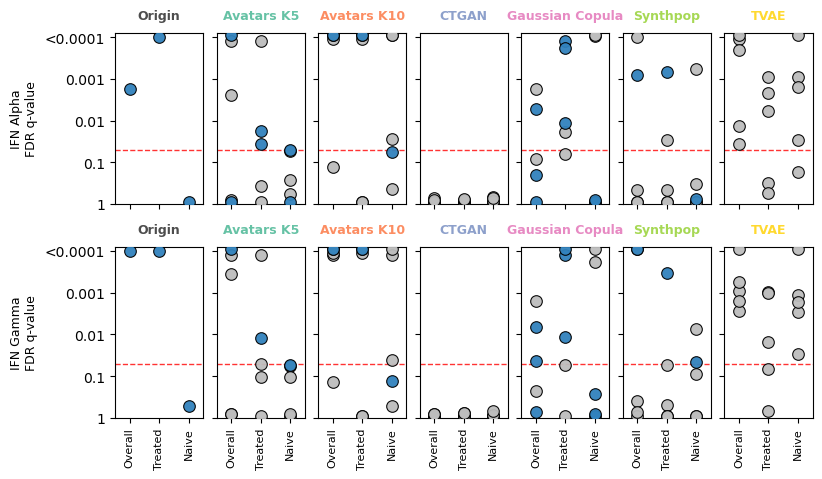

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from plot_synthetic_pathways import plot_origin_vs_synthetic_pathways

# seeds to combine across
seeds = [0, 1, 2, 3, 42]

# pathways of interest
terms = ['HALLMARK_INTERFERON_ALPHA_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE']

# dataset mapping short->display
DataSeed_Path = {
    'avatarsk5': 'Avatars K5',
    'avatarsk10': 'Avatars K10',
    'ctgan': 'CTGAN',
    'gaussiancopula': 'Gaussian Copula',
    'synthpop': 'Synthpop',
    'tvae': 'TVAE'
}
names = list(DataSeed_Path.values())
shorts = list(DataSeed_Path.keys())

# Build IpiSubgroups: dict[dataset_display] -> dict[subgroup] -> DataFrame with Seed column
IpiSubgroups = {}

# Origin (we assume origin files under Seed_42 as before)
origin_base = '../Melanoma/NarrowUtility/GSEA'
# read origin overall + subgroups (Origin may have separate folders)
or_grouped = {}
# Overall origin
p = f'{origin_base}/CRPR_PD/Seed_42/GSEA_Origin.csv'
df_overall = pd.read_csv(p)
df_overall = df_overall[df_overall['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_overall['Seed'] = 'origin'
or_grouped['Overall'] = df_overall

# IpiTreated origin
p = f'{origin_base}/Ipitreated/Seed_42/GSEA_Origin.csv'
df_it = pd.read_csv(p)
df_it = df_it[df_it['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_it['Seed'] = 'origin'
or_grouped['IpiTreated'] = df_it

# IpiNaive origin
p = f'{origin_base}/Ipinaive/Seed_42/GSEA_Origin.csv'
df_in = pd.read_csv(p)
df_in = df_in[df_in['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
df_in['Seed'] = 'origin'
or_grouped['IpiNaive'] = df_in

IpiSubgroups['Origin'] = or_grouped

# For each synthetic dataset, collect per-seed results and concatenate for each subgroup
for short_name, display_name in DataSeed_Path.items():
    grouped = {}
    # collect across seeds for each subgroup
    dfs_overall = []
    dfs_it = []
    dfs_in = []
    for s in seeds:
        # try reading files; skip if missing
        p_overall = f'../Melanoma/NarrowUtility/GSEA/CRPR_PD/Seed_{s}/GSEA_{short_name}_{s}.csv'
        p_it = f'../Melanoma/NarrowUtility/GSEA/Ipitreated/Seed_{s}/GSEA_{short_name}_{s}.csv'
        p_in = f'../Melanoma/NarrowUtility/GSEA/Ipinaive/Seed_{s}/GSEA_{short_name}_{s}.csv'

        try:
            df_o = pd.read_csv(p_overall)
            df_o = df_o[df_o['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_o['Seed'] = int(s)
            dfs_overall.append(df_o)
        except FileNotFoundError:
            # skip missing
            pass

        try:
            df_t = pd.read_csv(p_it)
            df_t = df_t[df_t['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_t['Seed'] = int(s)
            dfs_it.append(df_t)
        except FileNotFoundError:
            pass

        try:
            df_n = pd.read_csv(p_in)
            df_n = df_n[df_n['Term'].isin(terms)][['Term', 'FDR q-val']].copy()
            df_n['Seed'] = int(s)
            dfs_in.append(df_n)
        except FileNotFoundError:
            pass

    grouped['Overall'] = pd.concat(dfs_overall, ignore_index=True) if len(dfs_overall) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])
    grouped['IpiTreated'] = pd.concat(dfs_it, ignore_index=True) if len(dfs_it) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])
    grouped['IpiNaive'] = pd.concat(dfs_in, ignore_index=True) if len(dfs_in) > 0 else pd.DataFrame(columns=['Term', 'FDR q-val', 'Seed'])

    IpiSubgroups[display_name] = grouped

# Use the plotting function to create the figure that aggregates seeds
fig = plot_origin_vs_synthetic_pathways(
    IpiSubgroups=IpiSubgroups,
    pathways=terms,
    subgroups=['Overall', 'IpiTreated', 'IpiNaive'],
    seeds=seeds,
    figsize=(9, 5),
    savepath=None
)

fig.savefig(f"IpiSubgroupInterferon/CombinedSeeds_Melanoma_scatter.pdf", dpi=300, bbox_inches="tight", facecolor="white")